# LECTURE 12
**Topic:** Introduction to the Discrete Fourier Transform; Basic Examples  
**Textbook References:** Sections 3.1, 3.2

---

## Key Points

- The columns of the $N\times N$ DFT matrix $V$ (defined by $V_{nk}=e^{j(2\pi/N)kn}$) are orthogonal: $V^HV=NI$.
- Any signal $s$ decomposes as $s=Vc$ where $c=V^Hs/N$.
- **DFT (spectrum):** $S=V^Hs$ &emsp; **IDFT (signal):** $s=VS/N$
- $s$ is a sinusoid of frequency $\omega=2k\pi/N$ iff $S$ has only $S[k]\neq 0$.
- MATLAB/Python: `S = fft(s)`, `s = ifft(S)`


---
## Theory and Examples

### 1. The DFT in Practice

The 200-point signal:
```python
n = np.arange(200)
s = 4.7*np.cos(0.12*np.pi*n-1.3) + 3.8*np.cos(0.19*np.pi*n+0.8) + 5.1*np.cos(0.23*np.pi*n+2.4) + noise
S = np.fft.fft(s)
```
The FFT reveals sinusoidal components even in the presence of noise.

### 2-5. The DFT Matrix

The $N\times N$ matrix $V$ with entries $V_{nk} = e^{j(2\pi/N)kn}$:
- Column $k$ is a complex sinusoid at frequency $\omega_k = 2k\pi/N$
- Columns are orthogonal: $V^HV = NI$ (proved via geometric sum formula)
- For $v=e^{j2\pi/N}$, columns are formed by $v^0=1, v, v^2, \ldots, v^{N-1}$ raised to powers $n=0:N-1$
- These are the $N$ roots of $z^N=1$!


N=4: V^H V = N*I? True
  Column norms: ['2.0000', '2.0000', '2.0000', '2.0000']

N=6: V^H V = N*I? True
  Column norms: ['2.4495', '2.4495', '2.4495', '2.4495', '2.4495', '2.4495']



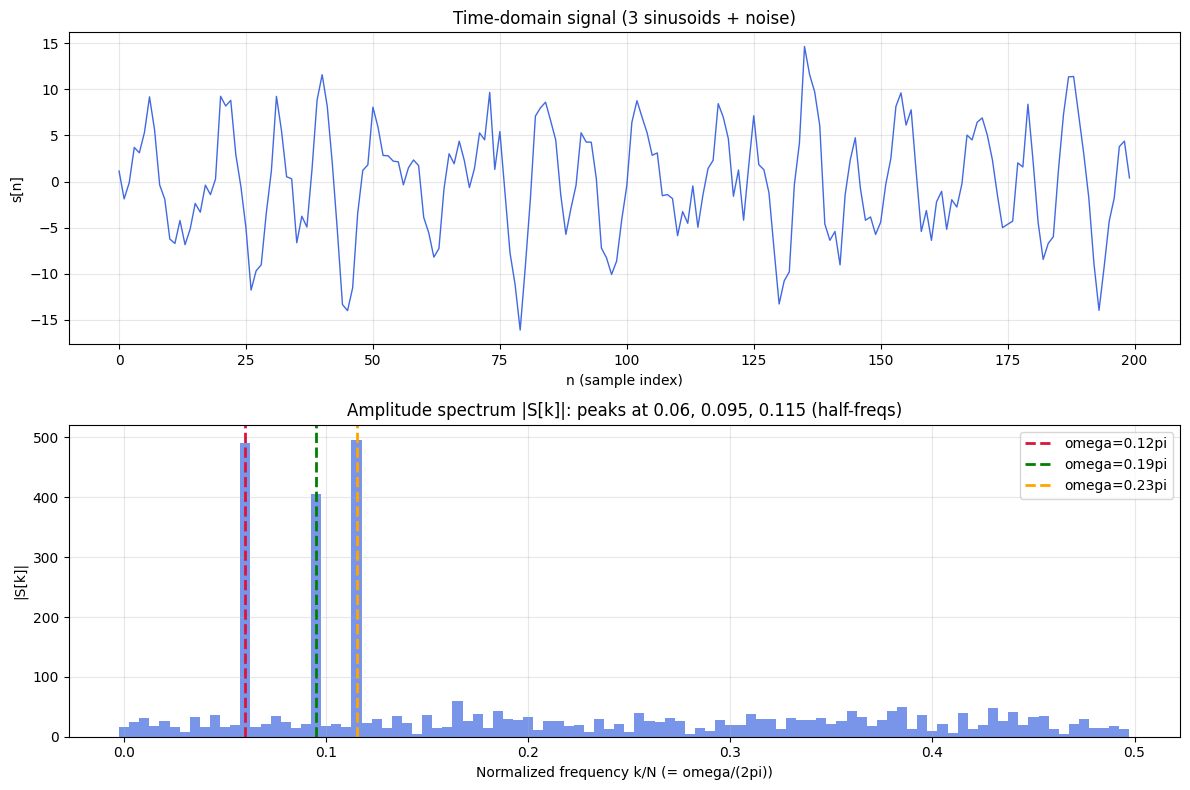

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Build V matrix for general N
def dft_matrix(N):
    n = np.arange(N).reshape(N,1)
    k = np.arange(N).reshape(1,N)
    return np.exp(1j * 2*np.pi/N * n * k)

# Verify DFT matrix properties for N=4 and N=6
for N in [4, 6]:
    V = dft_matrix(N)
    VHV = V.conj().T @ V
    print(f'N={N}: V^H V = N*I? {np.allclose(VHV, N*np.eye(N))}')
    print(f'  Column norms: {[f"{np.linalg.norm(V[:,k]):.4f}" for k in range(N)]}')
    print()

# Signal decomposition demo (from lecture)
np.random.seed(42)
N = 200
n = np.arange(N)
s = (4.7*np.cos(0.12*np.pi*n-1.3) + 
     3.8*np.cos(0.19*np.pi*n+0.8) + 
     5.1*np.cos(0.23*np.pi*n+2.4) + 
     2.0*np.random.randn(N))

S = np.fft.fft(s)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(n, s, 'royalblue', lw=1)
axes[0].set_title('Time-domain signal (3 sinusoids + noise)', fontsize=12)
axes[0].set_xlabel('n (sample index)'); axes[0].set_ylabel('s[n]')
axes[0].grid(True, alpha=0.3)

freqs = np.arange(N) / N  # normalized frequency (0 to 1)
axes[1].bar(freqs[:N//2], np.abs(S[:N//2]), width=1/N, color='royalblue', alpha=0.7)
axes[1].set_title('Amplitude spectrum |S[k]|: peaks at 0.06, 0.095, 0.115 (half-freqs)', fontsize=12)
axes[1].set_xlabel('Normalized frequency k/N (= omega/(2pi))')
axes[1].set_ylabel('|S[k]|')
# Mark expected peaks
for w, col, lbl in [(0.12, 'crimson', '0.12pi'), (0.19, 'green', '0.19pi'), (0.23, 'orange', '0.23pi')]:
    axes[1].axvline(w/2, color=col, lw=2, ls='--', label=f'omega={lbl}')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
### 6. Orthogonality Proof via Geometric Sum

For two different columns $v^{(k)}$ and $v^{(\ell)}$ of $V$:
$$\langle v^{(k)}, v^{(\ell)}\rangle = \sum_{n=0}^{N-1} v^{(\ell-k)n} = \frac{1-v^{(\ell-k)N}}{1-v^{(\ell-k)}} = 0$$

since $v^{(\ell-k)N} = e^{j2\pi(\ell-k)} = 1$ and $v^{(\ell-k)} \neq 1$ (since $\ell\neq k$).

For $k=\ell$: $\langle v^{(k)}, v^{(k)}\rangle = \sum_{n=0}^{N-1} 1 = N$. Thus $V^HV = NI$.

### 7. Example: $N=6$ DFT matrix

Frequencies: $\omega = 0, \pi/3, 2\pi/3, \pi, 4\pi/3, 5\pi/3$

For $s=[1,2,3,6,5,4]^T$: $c = \text{fft}(s)/6$

By hand: $c_0 = (1+2+3+6+5+4)/6 = 7/2$


In [2]:
# N=6 DFT example
N = 6
V6 = dft_matrix(N)
s6 = np.array([1,2,3,6,5,4], dtype=complex)

# Compute c = V^H s / N  (same as ifft(S) * N / N = ifft(S)... actually S = fft(s), c=S/N)
S6 = V6.conj().T @ s6   # = fft(s6)
c6 = S6 / N

print('=== N=6 DFT Example: s = [1,2,3,6,5,4] ===')
print(f'S = V^H s = {S6.round(4)}')
print(f'c = S/6   = {c6.round(4)}')

# Verify by hand for c0 and c1
c0_hand = (1+2+3+6+5+4)/6
print(f'c0 by hand = (1+2+3+6+5+4)/6 = 21/6 = {c0_hand:.4f}')

# Verify reconstruction
s_recon = V6 @ c6
print(f'Reconstructed s = V*c = {s_recon.real.round(4)}')
print(f'Match? {np.allclose(s_recon, s6)}')

# Compare with numpy fft
S_numpy = np.fft.fft(s6)
print(f'\nnp.fft.fft(s) = {S_numpy.round(4)}')
print(f'V^H s         = {S6.round(4)}')
print(f'Match? {np.allclose(S_numpy, S6)}')

=== N=6 DFT Example: s = [1,2,3,6,5,4] ===
S = V^H s = [21.+0.j     -6.+3.4641j -0.-0.j     -3.-0.j      0.-0.j     -6.-3.4641j]
c = S/6   = [ 3.5+0.j     -1. +0.5774j -0. -0.j     -0.5-0.j      0. -0.j
 -1. -0.5774j]
c0 by hand = (1+2+3+6+5+4)/6 = 21/6 = 3.5000
Reconstructed s = V*c = [1. 2. 3. 6. 5. 4.]
Match? True

np.fft.fft(s) = [21.+0.j     -6.+3.4641j  0.+0.j     -3.-0.j      0.+0.j     -6.-3.4641j]
V^H s         = [21.+0.j     -6.+3.4641j -0.-0.j     -3.-0.j      0.-0.j     -6.-3.4641j]
Match? True


---
### 8-10. DFT Notation and the Synthesis/Analysis Equations

**Spectrum (Analysis, DFT):**
$$S = V^H s \quad \text{(MATLAB/Python: S = fft(s))}$$

**Signal (Synthesis, IDFT):**
$$s = \frac{1}{N} V S \quad \text{(MATLAB/Python: s = ifft(S))}$$

| Time Domain | $\xrightarrow{\text{DFT}}$ | Frequency Domain |
|---|---|---|
| $s$ | $\leftrightarrow$ | $S = V^H s$ |
| $s = \frac{1}{N}VS$ | (synthesis) | $S$ = spectrum |

The matrix $V$ is **symmetric**: $V_{nk} = e^{j(2\pi/N)kn} = V_{kn}$. So $V^H = V^* \stackrel{\text{def}}{=} W$.


---
### 11-12. Example: Single Nonzero Entry in Spectrum

If $S = [1,0,0,0,0,0,0,0]^T$ (N=8, only $S[0]\neq 0$):

Since $k=0$: $s = \frac{1}{8}V\cdot S = \frac{1}{8}v^{(0)} = \frac{1}{8}[1,1,1,1,1,1,1,1]^T$

(Sinusoid at frequency $\omega=0$ = constant signal)

**Conversely:** starting from $s = \frac{1}{8}[1,1,\ldots,1]^T$:
$S = V^H s = \frac{1}{8}V^H v^{(0)} = \frac{1}{8}[N,0,\ldots,0]^T = [1,0,\ldots,0]^T$

(Since columns of $V$ are orthogonal: $\langle v^{(k)}, v^{(0)}\rangle = N\delta_{k,0}$)


=== Single nonzero S[0]=1, rest zero ===
S = [1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
s = ifft(S) = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
  = (1/8)*[1,1,1,1,1,1,1,1] = constant sinusoid at omega=0

=== Single nonzero S[4]=1 (omega=pi) ===
s = ifft(S) = [ 0.125 -0.125  0.125 -0.125  0.125 -0.125  0.125 -0.125]
  = (1/8)*(-1)^n (alternating: highest frequency)

=== Single nonzero S[3]=1 (omega=3pi/4) ===
s = ifft(S) = [ 0.125 +0.j     -0.0884+0.0884j  0.    -0.125j   0.0884+0.0884j
 -0.125 +0.j      0.0884-0.0884j  0.    +0.125j  -0.0884-0.0884j]
  = (1/8)*exp(j*3pi/4*n) — complex sinusoid


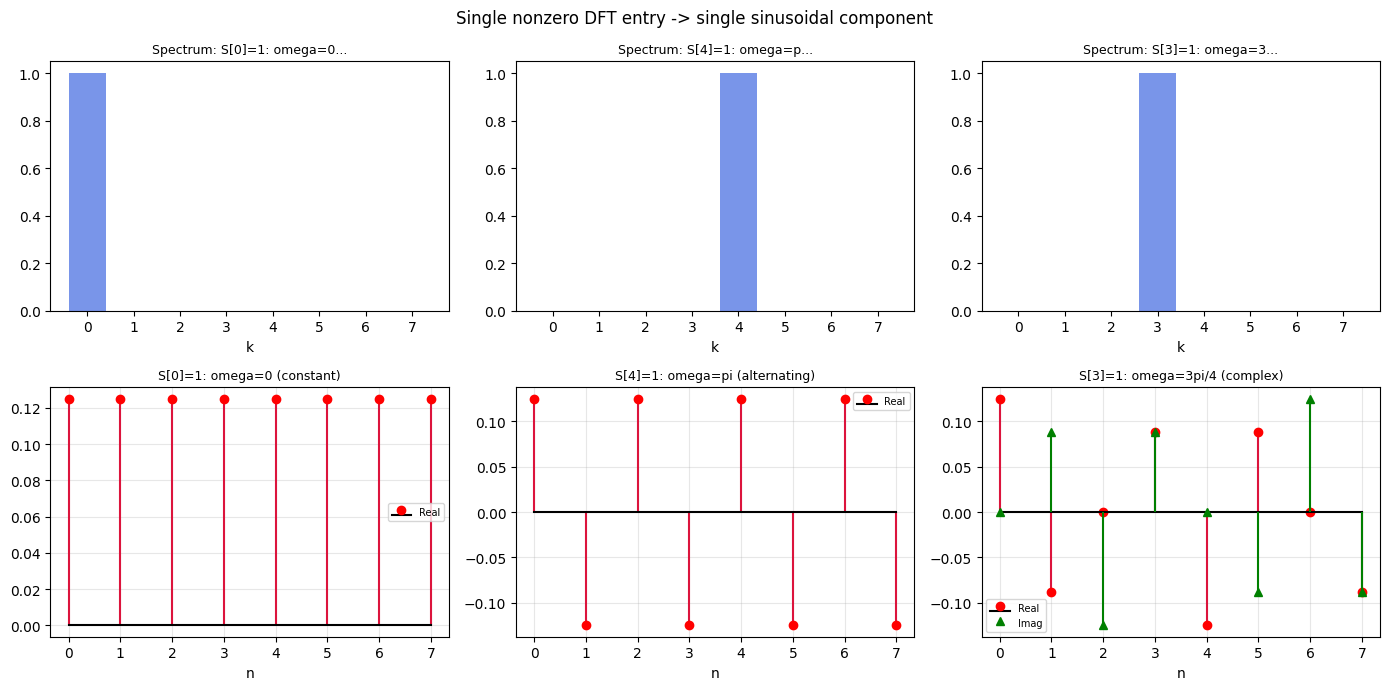

In [3]:
# Demonstrate single nonzero DFT entry
N = 8
V8 = dft_matrix(N)

print('=== Single nonzero S[0]=1, rest zero ===')
S_test = np.zeros(N, dtype=complex); S_test[0] = 1
s_test = np.fft.ifft(S_test)
print(f'S = {S_test}')
print(f's = ifft(S) = {s_test.real.round(4)}')
print(f'  = (1/8)*[1,1,1,1,1,1,1,1] = constant sinusoid at omega=0')

print('\n=== Single nonzero S[4]=1 (omega=pi) ===')
S_test2 = np.zeros(N, dtype=complex); S_test2[4] = 1
s_test2 = np.fft.ifft(S_test2)
print(f's = ifft(S) = {s_test2.real.round(4)}')
print(f'  = (1/8)*(-1)^n (alternating: highest frequency)')

print('\n=== Single nonzero S[3]=1 (omega=3pi/4) ===')
S_test3 = np.zeros(N, dtype=complex); S_test3[3] = 1
s_test3 = np.fft.ifft(S_test3)
print(f's = ifft(S) = {s_test3.round(4)}')
print(f'  = (1/8)*exp(j*3pi/4*n) — complex sinusoid')

# Plot all three
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for col_idx, (S_t, s_t, title) in enumerate([
    (S_test, s_test, 'S[0]=1: omega=0 (constant)'),
    (S_test2, s_test2, 'S[4]=1: omega=pi (alternating)'),
    (S_test3, s_test3, 'S[3]=1: omega=3pi/4 (complex)')
]):
    # Spectrum
    axes[0][col_idx].bar(np.arange(N), np.abs(S_t), color='royalblue', alpha=0.7)
    axes[0][col_idx].set_title(f'Spectrum: {title[:15]}...', fontsize=9)
    axes[0][col_idx].set_xlabel('k')
    # Signal
    axes[1][col_idx].stem(np.arange(N), s_t.real, linefmt='crimson', markerfmt='ro', basefmt='k', label='Real')
    if np.any(np.abs(s_t.imag) > 1e-10):
        axes[1][col_idx].stem(np.arange(N), s_t.imag, linefmt='green', markerfmt='g^', basefmt=' ', label='Imag')
    axes[1][col_idx].set_title(title, fontsize=9)
    axes[1][col_idx].set_xlabel('n'); axes[1][col_idx].grid(True,alpha=0.3); axes[1][col_idx].legend(fontsize=7)

plt.suptitle('Single nonzero DFT entry -> single sinusoidal component', fontsize=12)
plt.tight_layout(); plt.show()

In [4]:
# Verify with geometric sum formula
print('=== Geometric Sum Formula Verification ===')
N = 8
v = np.exp(1j*2*np.pi/N)

for ell_minus_k in range(-3, N+3):
    if ell_minus_k % N == 0:
        total = N
    else:
        z = v**ell_minus_k
        total = sum(z**n for n in range(N))
    if abs(total) > 0.01:
        print(f'  ell-k={ell_minus_k:+3d}: sum = {total:.4f}  (= N={N}? {np.isclose(abs(total),N)})')
    else:
        print(f'  ell-k={ell_minus_k:+3d}: sum = {total:.2e}  (= 0? {np.isclose(abs(total),0)})')

=== Geometric Sum Formula Verification ===
  ell-k= -3: sum = 8.88e-16-4.44e-16j  (= 0? True)
  ell-k= -2: sum = 8.88e-16-8.88e-16j  (= 0? True)
  ell-k= -1: sum = 3.33e-16-1.11e-15j  (= 0? True)
  ell-k= +0: sum = 8.0000  (= N=8? True)
  ell-k= +1: sum = -5.55e-16-7.77e-16j  (= 0? True)
  ell-k= +2: sum = -8.88e-16-8.88e-16j  (= 0? True)
  ell-k= +3: sum = -7.77e-16-4.44e-16j  (= 0? True)
  ell-k= +4: sum = -1.78e-15+0.00e+00j  (= 0? True)
  ell-k= +5: sum = -2.11e-15+8.88e-16j  (= 0? True)
  ell-k= +6: sum = -2.66e-15+2.66e-15j  (= 0? True)
  ell-k= +7: sum = -2.78e-15+6.66e-15j  (= 0? True)
  ell-k= +8: sum = 8.0000  (= N=8? True)
  ell-k= +9: sum = -3.89e-15-9.66e-15j  (= 0? True)
  ell-k=+10: sum = -4.44e-15-4.44e-15j  (= 0? True)


---
## Summary

| Formula | Description |
|---|---|
| $V_{nk} = e^{j(2\pi/N)kn}$ | DFT matrix entry |
| $V^HV = NI$ | Orthogonality |
| $S = V^Hs$ | Analysis (DFT) |
| $s = VS/N$ | Synthesis (IDFT) |
| `S = fft(s)` | Python/MATLAB |
| `s = ifft(S)` | Python/MATLAB |

### Mistakes to Avoid
1. Confusing $S = V^Hs$ (DFT) with $s = VS/N$ (IDFT): **analysis** multiplies by $V^H$, **synthesis** by $V$.
2. The factor of $N$: `fft(s)` gives $S=V^Hs$, but `ifft(S)` automatically divides by $N$. Don't add an extra $1/N$.
3. Forgetting that a single nonzero $S[k]$ gives a **complex** sinusoid in general — to get a real sinusoid, you need both $S[k]$ and $S[N-k]$ to be conjugates.
